Mounted at /content/drive
Loading model and data...
Loaded model and test data:
   Test samples: 10861
   Classes in class_names: 38
   Classes actually in y_test: 38

Generating predictions...

COMPREHENSIVE CLASSIFICATION REPORT:

Top 10 Performing Classes:


,precision,recall,f1-score,support
Corn_(maize)___healthy,0.995708,1.000000,0.997849,232.0
Orange___Haunglongbing_(Citrus_greening),0.997278,0.997278,0.997278,1102.0
Corn_(maize)___Common_rust_,0.995816,0.995816,0.995816,239.0
Squash___Powdery_mildew,0.991870,0.997275,0.994565,367.0
Strawberry___Leaf_scorch,0.986667,1.000000,0.993289,222.0
Blueberry___healthy,0.986799,0.996667,0.991708,300.0
Grape___Leaf_blight_(Isariopsis_Leaf_Spot),0.986175,0.995349,0.990741,215.0
Soybean___healthy,0.983543,0.998035,0.990736,1018.0
Cherry_(including_sour)___healthy,0.988304,0.988304,0.988304,171.0
Grape___healthy,1.000000,0.976471,0.988095,85.0



GENERATING NORMALIZED CONFUSION MATRIX...


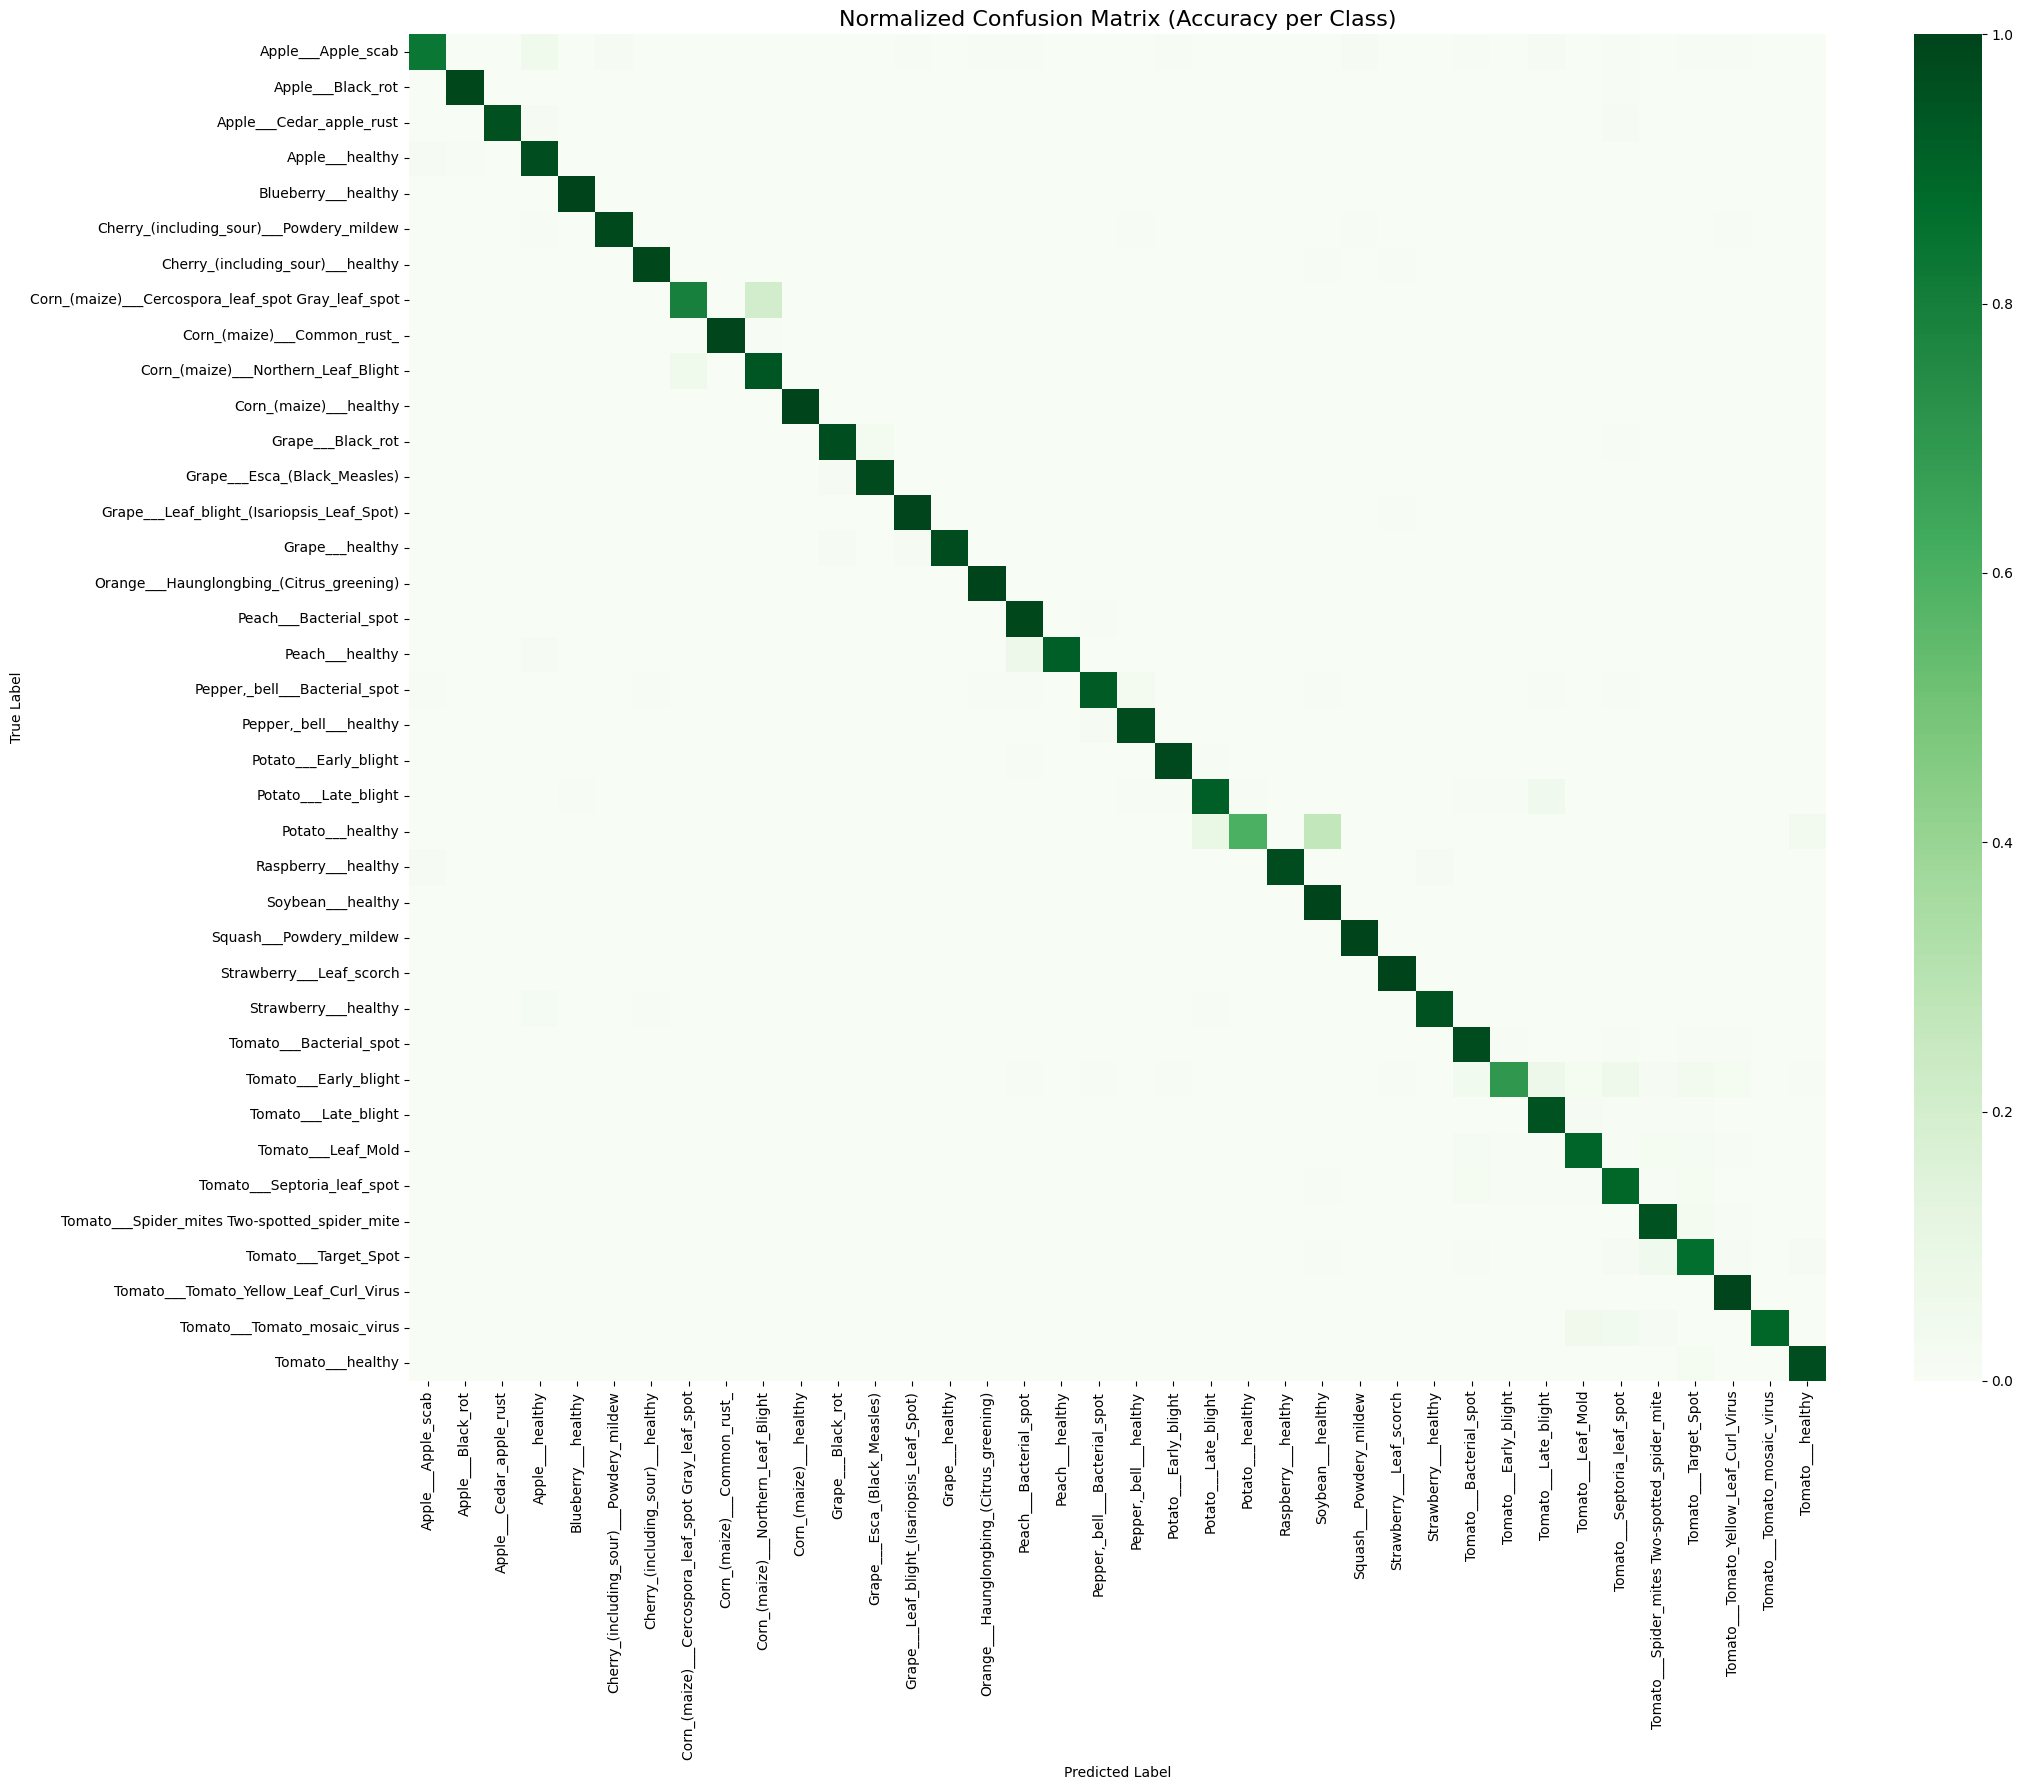


ERROR ANALYSIS:
Total Errors: 393 (3.62%)

Top 5 Most Frequent Errors (True -> Predicted):


,,0
True_Class,Pred_Class,
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,Corn_(maize)___Northern_Leaf_Blight,21
Tomato___Early_blight,Tomato___Late_blight,14
Tomato___Target_Spot,Tomato___Spider_mites Two-spotted_spider_mite,14
Tomato___Early_blight,Tomato___Septoria_leaf_spot,12
Corn_(maize)___Northern_Leaf_Blight,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,11



PLOTTING ROC CURVES...


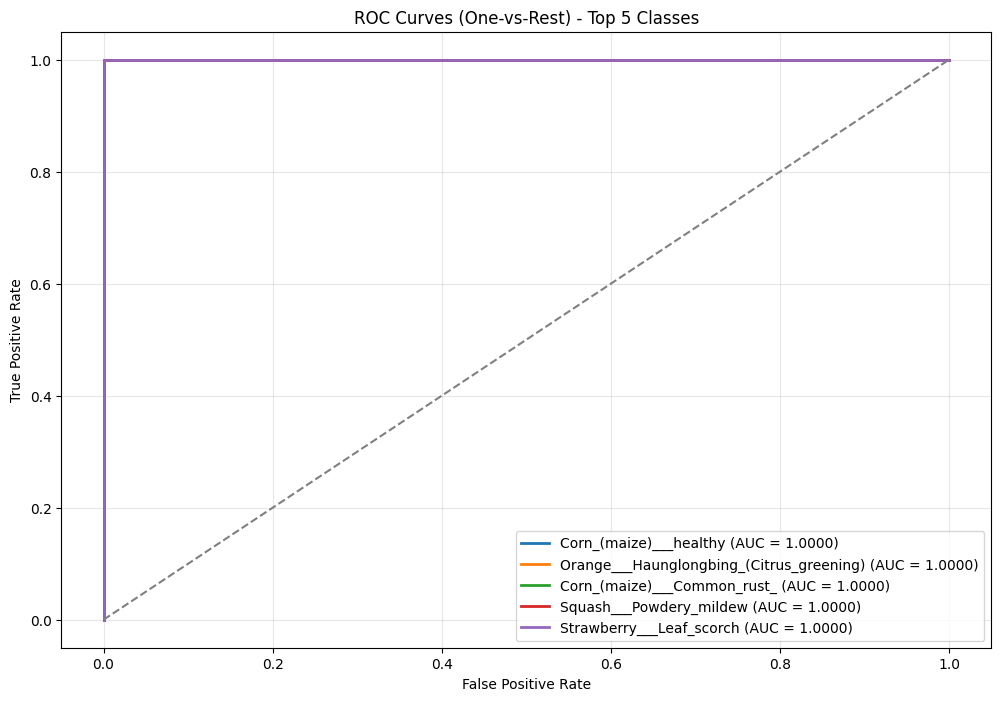


PROBABILITY DISTRIBUTION...


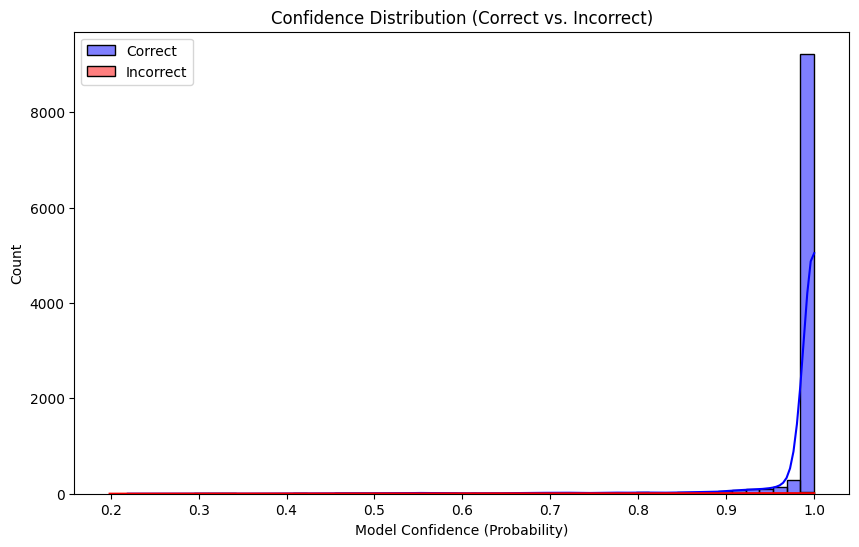


FEATURE IMPORTANCE ANALYSIS...


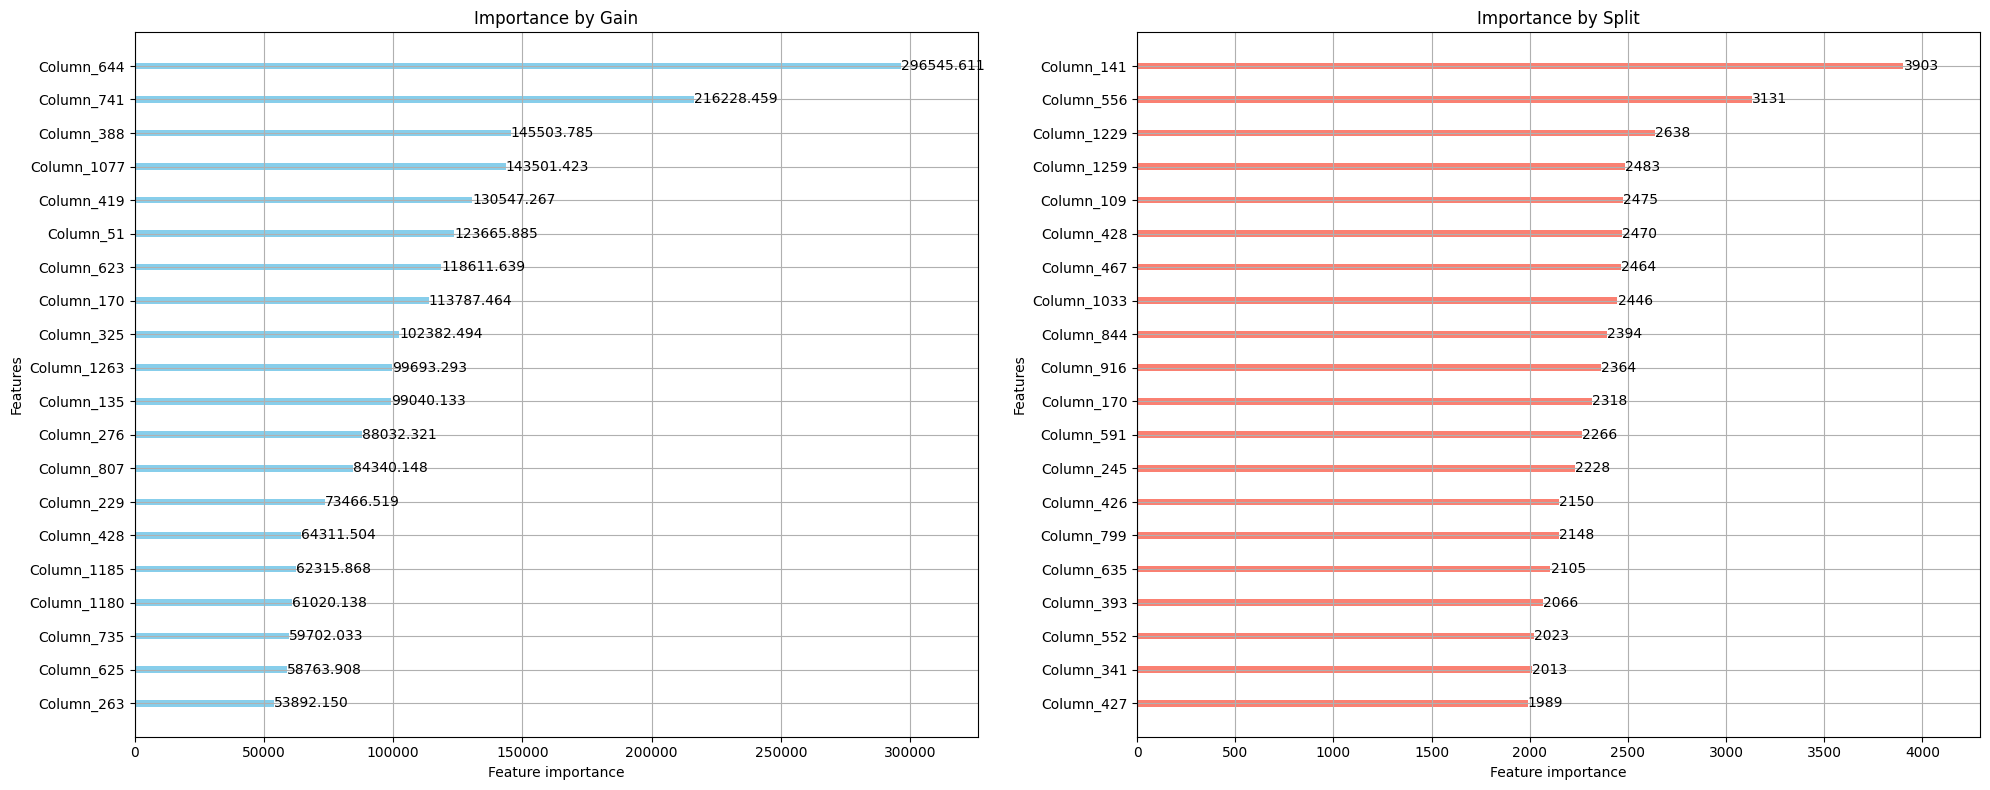


CHECKING FOR TINY NN COMPARISON...


340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Model Comparison Results:
   LightGBM Accuracy: 96.38%
   Tiny NN Accuracy:  98.82%

Evaluation Complete! Files saved to: /content/drive/MyDrive/PlantVillage_Project/evaluation/lightgbm/


In [1]:
"""
# LightGBM Model Evaluation Notebook
Comprehensive analysis of the accuracy PlantVillage Model
"""

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from IPython.display import display, Image
import lightgbm as lgb

# 1. Load the trained model and data
print("Loading model and data...")
model_path = '/content/drive/MyDrive/PlantVillage_Project/models/lightgbm/lightgbm_model.pkl'
data_path = "/content/drive/MyDrive/PlantVillage_Project/data/processed/efficientnetv2_features.npz"

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found at {model_path}. Run training first!")

model = joblib.load(model_path)
data = np.load(data_path)

# Prepare data
X = data['features']
y = np.argmax(data['labels'], axis=1)
class_names = data['class_names']

# Use Stratified Split instead of slicing to ensure all 38 classes are in test set
_, X_test, _, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # This ensures all 38 classes are represented
)

print(f"Loaded model and test data:")
print(f"   Test samples: {X_test.shape[0]}")
print(f"   Classes in class_names: {len(class_names)}")
print(f"   Classes actually in y_test: {len(np.unique(y_test))}")

# 2. Generate Predictions
print("\nGenerating predictions...")
y_probs = model.predict(X_test, num_iteration=model.best_iteration)
y_pred_classes = np.argmax(y_probs, axis=1)

# 3. Comprehensive Classification Report
print("\nCOMPREHENSIVE CLASSIFICATION REPORT:")
# Added 'labels' parameter to prevent ValueError when test set is missing classes
report = classification_report(
    y_test,
    y_pred_classes,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    digits=4,
    zero_division=0,
    output_dict=True
)

# Convert to DataFrame for visualization
report_df = pd.DataFrame(report).transpose()
print("\nTop 10 Performing Classes:")
display(report_df.iloc[:-3].sort_values(by='f1-score', ascending=False).head(10))

# Save full report as JSON
save_dir = '/content/drive/MyDrive/PlantVillage_Project/evaluation/lightgbm/'
os.makedirs(save_dir, exist_ok=True)
with open(os.path.join(save_dir, 'full_classification_report.json'), 'w') as f:
    json.dump(report, f, indent=4)

# 4. Normalized Confusion Matrix
print("\nGENERATING NORMALIZED CONFUSION MATRIX...")
cm = confusion_matrix(y_test, y_pred_classes, labels=np.arange(len(class_names)))
# Handle potential division by zero for classes with 0 samples in test set
cm_sum = cm.sum(axis=1)[:, np.newaxis]
cm_normalized = np.divide(cm.astype('float'), cm_sum, out=np.zeros_like(cm.astype('float')), where=cm_sum!=0)

plt.figure(figsize=(22, 18))
sns.heatmap(cm_normalized, annot=False, cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix (Accuracy per Class)', fontsize=16)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'normalized_confusion_matrix.png'))
plt.show()

# 5. Error Analysis
print("\nERROR ANALYSIS:")
errors_idx = np.where(y_pred_classes != y_test)[0]
print(f"Total Errors: {len(errors_idx)} ({len(errors_idx)/len(y_test):.2%})")

error_df = pd.DataFrame({
    'True_Class': [class_names[i] for i in y_test[errors_idx]],
    'Pred_Class': [class_names[i] for i in y_pred_classes[errors_idx]],
    'Confidence': [np.max(y_probs[i]) for i in errors_idx]
})

print("\nTop 5 Most Frequent Errors (True -> Predicted):")
display(error_df.groupby(['True_Class', 'Pred_Class']).size().sort_values(ascending=False).head(5))

# 6. ROC Curves for Top Classes
print("\nPLOTTING ROC CURVES...")
plt.figure(figsize=(12, 8))
top_5_f1 = report_df.iloc[:-3].sort_values('f1-score', ascending=False).head(5).index.tolist()

for class_name in top_5_f1:
    class_idx = np.where(class_names == class_name)[0][0]
    y_true_binary = (y_test == class_idx).astype(int)
    if np.sum(y_true_binary) > 0: # Ensure class exists in test set
        fpr, tpr, _ = roc_curve(y_true_binary, y_probs[:, class_idx])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest) - Top 5 Classes')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(save_dir, 'top_classes_roc.png'))
plt.show()

# 7. Probability Distribution
print("\nPROBABILITY DISTRIBUTION...")
correct_mask = (y_pred_classes == y_test)
correct_probs = [y_probs[i, y_test[i]] for i in range(len(y_test)) if correct_mask[i]]
wrong_probs = [np.max(y_probs[i]) for i in range(len(y_test)) if not correct_mask[i]]

plt.figure(figsize=(10, 6))
if len(correct_probs) > 0:
    sns.histplot(correct_probs, bins=50, color='blue', label='Correct', alpha=0.5, kde=True)
if len(wrong_probs) > 0:
    sns.histplot(wrong_probs, bins=50, color='red', label='Incorrect', alpha=0.5, kde=True)
plt.title('Confidence Distribution (Correct vs. Incorrect)')
plt.xlabel('Model Confidence (Probability)')
plt.legend()
plt.savefig(os.path.join(save_dir, 'probability_distribution.png'))
plt.show()

# 8. Feature Importance
print("\nFEATURE IMPORTANCE ANALYSIS...")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
lgb.plot_importance(model, max_num_features=20, importance_type='gain', ax=ax1, title='Importance by Gain', color='skyblue')
lgb.plot_importance(model, max_num_features=20, importance_type='split', ax=ax2, title='Importance by Split', color='salmon')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'feature_importance_dual.png'))
plt.show()

# 9. Model Comparison
print("\nCHECKING FOR TINY NN COMPARISON...")
nn_path = '/content/drive/MyDrive/PlantVillage_Project/models/tiny_nn/tiny_nn_best.h5'
if os.path.exists(nn_path):
    try:
        from tensorflow.keras.models import load_model
        tiny_nn = load_model(nn_path)
        y_pred_nn = np.argmax(tiny_nn.predict(X_test), axis=1)
        nn_acc = np.mean(y_pred_nn == y_test)
        lgb_acc = np.mean(y_pred_classes == y_test)
        print(f"Model Comparison Results:\n   LightGBM Accuracy: {lgb_acc:.2%}\n   Tiny NN Accuracy:  {nn_acc:.2%}")
    except Exception as e:
        print(f"Could not compare models: {e}")
else:
    print("Tiny NN model not found. Skipping comparison.")

print("\nEvaluation Complete! Files saved to:", save_dir)
